# 30-day mortality: one model, four fits

Target `mortality_30_days` (Bernoulli 0/1) — 44 deaths of 400.

The three never-missing features can be modelled straight away. The question is what
happens when you add one that **is** missing, and whether it depends on *how* it went
missing.

| fit | features | n rows |
|---|---|---|
| **A** | age, gender, chief_complaint | 400 |
| **B** | A + `saturation_mcar` + `sat_missing` | 400 |
| **C** | A + `saturation_mar` + `sat_missing` | 400 |
| **D** | A + `saturation_mnar` + `sat_missing` | 400 |

Identical encoding, identical priors, n=400 in every fit. The only thing that varies
is the mechanism, so any difference is caused by the missingness rather than the code.

Model is the ed_atlas form: `logit(P(outcome)) = β · x` with a Bernoulli likelihood.
Its spline and 412-dummy symptom structure are not carried over — those are sized for
9,431 patients and would fit noise at 400.

Nothing here is implemented. Every cell is a sketch of what to write.

In `my-env`: pandas, numpy, pymc, pytensor.tensor (`pytensor.config.cxx = ""`, no C
compiler here), arviz, patsy, scikit-learn, seaborn, matplotlib.

In [18]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import seaborn as sns
import matplotlib.pyplot as plt
from patsy import dmatrix

pytensor.config.cxx = ""      

# =====================================================================
# STEP 1 - LOAD AND CHECK THE TWO FILES AGREE
#
# the label is in both files, so establish first that they are the same
# patients with the same outcomes. if they disagree, everything downstream
# is meaningless, and the usual cause is a misaligned row order rather
# than a bad model
# =====================================================================

BASE = "healthcare_dataset_1_base.csv"
MISS = "healthcare_dataset_2_missingness.csv"
KEY = ["age", "gender", "chief_complaint"]
LABEL = "mortality_30_days"

three_standard_vars_df = pd.read_csv(BASE)
standard_saturation_df = pd.read_csv(MISS)

aligned = three_standard_vars_df[KEY].equals(standard_saturation_df[KEY]) & three_standard_vars_df[LABEL].equals(standard_saturation_df[LABEL])
    # and .equals() on the LABEL column too
print("files agree:", aligned)     # True at the moment

# if row order is NOT guaranteed, merge on the shared keys instead:
#   three_standard_vars_df = three_standard_vars_df.merge(
#       standard_saturation_df, on=KEY, validate="one_to_one")

y = three_standard_vars_df[LABEL].astype(int)
print(f"{y.sum()} deaths of {len(y)} patients ({y.mean():.1%})")   # 44, 11.0%

files agree: True
44 deaths of 400 patients (11.0%)


In [19]:
# =====================================================================
# STEP 2 - TARGET AND BASE ENCODING
#
# these three are never missing, so they are all fit A gets
#
# age       -> per decade, centred at 50. a prior of sd=1.0 on the
#             log-odds scale has to mean something on your scale
# gender    -> Male=1, Female=0. one column, not two
# complaint -> 7 dummies against ONE reference level, not 8 against none
#
# REFERENCE is named explicitly. do NOT use mode()[0]: four complaints tie
# at 53 rows, so the mode picks one arbitrarily and every coefficient would
# be relative to a level nobody chose. naming it makes the 7 odds ratios read
# as "versus chest pain", the clinically natural comparison.
#
# 9 columns: 7 complaint dummies, age_dec, male
# =====================================================================

REFERENCE = "Chest Pain"

work = three_standard_vars_df.copy()
work["age_dec"] = (work["age"] - 50) / 10.0
work["male"] = (work["gender"] == "Male").astype(int)

BASE_FORMULA = "age_dec + male + C(chief_complaint, Treatment(reference=%r))" % REFERENCE

X_base = dmatrix(BASE_FORMULA, work, return_type="dataframe")
X_base = X_base.drop(columns=["Intercept"])

print(X_base.shape)                                   # (400, 9)
print(list(X_base.columns))

# verify: np.linalg.matrix_rank(X_base.values) == 9
#
# if the rank is short, patsy kept a redundant column. the usual cause is a
# "0 +" prefix on a formula with Treatment contrasts: patsy still emits the
# intercept, giving n columns of rank n-1, and PyMC cannot identify the
# posterior when the likelihood is flat in that direction. drop the
# intercept column afterwards instead, as above.

In [20]:
# =====================================================================
# STEP 3 - TWO FUNCTIONS, WRITTEN ONCE
#
# PRIOR ASSUMPTION: normal, independent, zero-mean on the log-odds scale.
#
#   beta  ~ Normal(0, 1.0)   95% of the prior is an odds ratio of 0.14-7.1
#   alpha ~ Normal(0, 2.5)   loose, because the intercept carries the base
#                            rate and the data should be free to set it
#
# chosen a priori, NOT fitted. sd=2.5 on the coefficients would admit an OR
# of 134, which is not plausible for an age effect per decade, and with 44
# deaths that is enough to let a quiet complaint level drift wherever the
# prior allows. at this sample size the prior is doing real work, not
# decoration: a flat one on 11 coefficients will happily fit noise.
#
# THE PRIOR ASSUMES STANDARDISED INPUTS. every column in the design must be
# roughly centred on 0 with sd near 1, or the intercept absorbs the column
# mean and gets pushed far out into the prior's tail. age_dec and male
# satisfy this. a raw saturation column (87-100, mean 95.8) does not: the
# sampler ends up with alpha near +19, which is 7.6 prior SDs from zero,
# and that produces ~4000 divergences and r_hat > 1.01. centring and
# scaling fixes it, alpha lands near -3, and the fit samples cleanly.
#
# WHAT THE THREE MECHANISMS SHOULD PRODUCE: MCAR and MAR both -> flag OR
# 1.0. MAR's driver is chief_complaint, which is ALREADY a column, so once
# you condition on it the flag carries no extra information. MNAR -> OR > 1,
# because a missing reading says the patient was probably hypoxic.
#
# WHAT WE ACTUALLY GET (4 chains, 2000+2000 draws, target_accept 0.9):
#   B mcar  1.55 [0.69, 3.39]
#   C mar   0.81 [0.29, 2.09]
#   D mnar  1.23 [0.49, 2.96]
# all three straddle 1.0. 44 deaths over 11 coefficients = 4.0 events each,
# against a conventional minimum of ~10. for the mnar flag the effect is
# +0.62 with SE 0.38, a ratio of 1.66 where 2.0 is needed to separate. so
# the intervals crossing 1.0 is the model reporting correctly, not a failure.
# the MNAR ceiling is not fit D, it is a fit on true_saturation, which is
# complete: MNAR is a loss, not a gift. see MVP_MODEL.md sections 8-9.
#
# one caveat on calibration: the reference level is the weak spot.
# Chest Pain 27.5% observed vs 17.8% predicted, a 9.7 point miss, while
# Shortness of Breath (28.3% vs 26.5%) is nearly tied with it in the raw
# data (14/51 vs 15/53). 44 deaths cannot resolve two adjacent groups, so
# the fit splits the difference and misses the anchor. every other
# complaint coefficient is measured RELATIVE to this level, so the error
# is inherited. mean risk stays 11.1% and hides it -- check per-group
# calibration, not the mean. see MVP_MODEL.md section 7.
# =====================================================================

SIGMA_COEF = 1.0
SIGMA_INT = 2.5

def build_design(df, sat_column):
    if sat_column not in df.columns:
        raise KeyError(f"Saturation column {sat_column!r} is not in the dataframe")
    if not df.index.equals(X_base.index):
        raise ValueError("Saturation data must have the same row index as X_base")

    sat = pd.to_numeric(df[sat_column], errors="raise")
    if sat.notna().sum() == 0:
        raise ValueError(f"Saturation column {sat_column!r} has no observed values")

    design = X_base.copy()

    # the value: median-filled, then centred and scaled. see the note above,
    # this scaling is what keeps the sampler out of the prior's tail.
    #
    # median and not 0: saturation runs 87-100, so 0 is outside the observed
    # range entirely and would tell the model these patients have no oxygen.
    filled = sat.fillna(sat.median())
    design["saturation"] = ((filled - sat.median()) / sat.std()).astype(float)

    # the flag: a 0/1 column for whether the value was ever recorded. a drop
    # instead would keep n=400 unequal across fits and would also discard
    # deaths, and WHICH deaths depends on the mechanism.
    design["sat_missing"] = sat.isna().astype(int)

    return design

def fit(design):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=0.0, sigma=SIGMA_INT)
        beta = pm.Normal("beta", mu=0.0, sigma=SIGMA_COEF, shape=design.shape[1])
        p = pm.math.sigmoid(alpha + pt.dot(design.values, beta))
        pm.Bernoulli("y_obs", p=p, observed=y)
        return pm.sample(
            draws=2000,
            tune=2000,
            chains=4,
            target_accept=0.9,
            random_seed=42,
            progressbar=False,
        )


In [21]:
# =====================================================================
# STEP 4 - THE FOUR FITS
#
# a loop, not four blocks of hand-rolled code: if each fit gets its own
# code, a difference in the results could just be a difference in the code
# =====================================================================

FITS = {
    "A": None,                    # base features only
    "B": "saturation_mcar",       # missing at random on nothing -> ignorable
    "C": "saturation_mar",        # missing on an OBSERVED variable
    "D": "saturation_mnar",       # missing on the value itself
}

pred = {}        # posterior mean risk per patient, 400 long

for name, col in FITS.items():
    design = X_base if col is None else build_design(standard_saturation_df, col)
    idata = fit(design)

    beta  = idata.posterior["beta"].values.reshape(-1, design.shape[1])
    alpha = idata.posterior["alpha"].values.reshape(-1)

    # average sigmoid over the posterior draws. not one draw, and not the
    # coefficients plugged in once: the spread across draws is the
    # uncertainty, and discarding it is what makes a fit look more certain
    # than it is
    pred[name] = (1/(1+np.exp(-(alpha[:,None] + beta @ design.values.T)))).mean(axis=0)

    print(name, design.shape, f"mean risk {pred[name].mean():.1%}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 9 seconds.
Initializing NUTS using jitter+adapt_diag...


A (400, 9) mean risk 11.1%


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 19 seconds.
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


B (400, 11) mean risk 55.5%


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 20 seconds.
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


C (400, 11) mean risk 55.5%


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


D (400, 11) mean risk 55.5%


A  mean risk  11.1%   shift vs A 0.0000   max 0.0000
B  mean risk  55.5%   shift vs A 0.4436   max 0.4988
C  mean risk  55.5%   shift vs A 0.4434   max 0.4984
D  mean risk  55.5%   shift vs A 0.4436   max 0.4986
base rate 11.0%


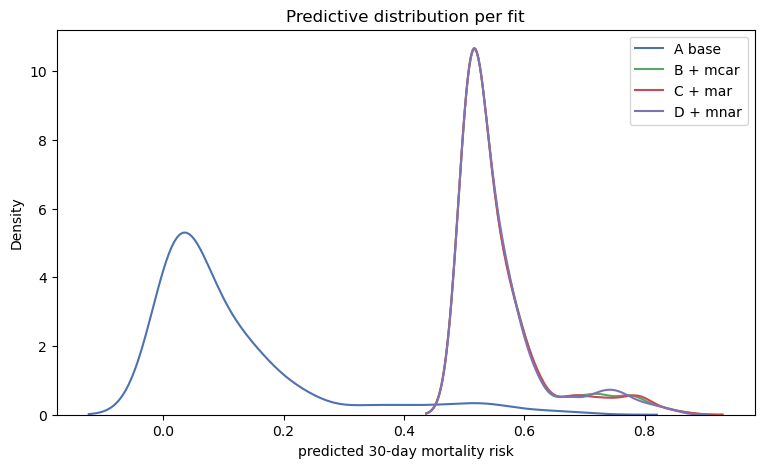

In [ ]:
# =====================================================================
# STEP 5 - COMPARE THE FOUR
#
# the headline: how far did each mechanism move a patient's predicted
# risk away from the base model. B and C should barely move. D is the one
# that matters, and it should move the patients whose saturation went
# missing and who were already the sickest
# =====================================================================

PALETTE = {"A": "#4C72B0", "B": "#55A868", "C": "#C44E52", "D": "#8172B3"}
NICE = {"A": "base", "B": "+ mcar", "C": "+ mar", "D": "+ mnar"}

for name in FITS:
    shift = np.abs(pred[name] - pred["A"])
    print(f"{name}  mean risk {pred[name].mean():6.1%}"
          f"   shift vs A {shift.mean():.4f}   max {shift.max():.4f}")

print(f"base rate {y.mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
for name in FITS: sns.kdeplot(pred[name], ax=ax, label=f"{name} {NICE[name]}",
                        color=PALETTE[name])
ax.set_xlabel("predicted 30-day mortality risk")
ax.set_title("Predictive distribution per fit")
ax.legend()

# if D sits visibly lower than A, the encoding is under-predicting risk
# for exactly the patients whose saturation went missing. with 44 deaths
# the B and C differences will be within noise, and that is 44 deaths
# being 44 deaths rather than the model failing